In [1]:
# connect to google drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd
import numpy as np
import scipy
from pathlib import Path

import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
# paths
data_path = Path('/content/drive/MyDrive/courses/ml_basics/datasets/Ames housing/') # replace with your path to the dataset!
fields_description_path = data_path/'data_description.txt'
dataset_path = data_path/'AmesHousing.csv'

# get fields description
with open(fields_description_path, 'r') as f:
    fields_description = f.read()

# get the dataset
df = pd.read_csv(dataset_path, na_values='NA', index_col='Order')
df.head(10)

,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
Order,,,,,,,,,,,,,,,,,,,,,
1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900
6,527105030,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2010,WD,Normal,195500
7,527127150,120,RL,41.0,4920,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,213500
8,527145080,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,0,NaN,NaN,NaN,0,1,2010,WD,Normal,191500
9,527146030,120,RL,39.0,5389,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,3,2010,WD,Normal,236500


# Managing Outliers

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import LocalOutlierFactor
from sklearn.ensemble import IsolationForest
from sklearn.cluster import DBSCAN
from sklearn.svm import OneClassSVM
from scipy import stats
import statsmodels.api as sm

In [5]:
# Choosing columns for illustration
x_column = 'Gr Liv Area'
y_column = 'SalePrice'

### Step 1: Scatter Plot for Outlier Visualization

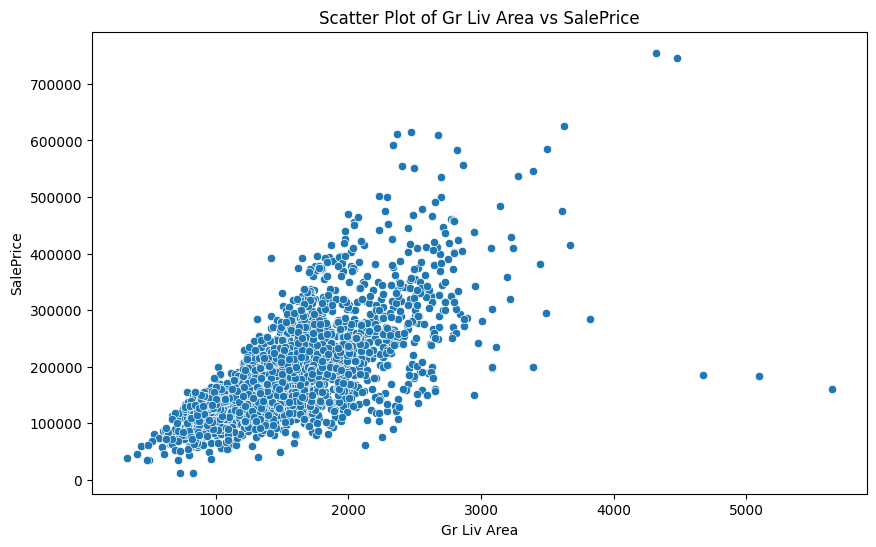

In [6]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df[x_column], y=df[y_column])
plt.title(f'Scatter Plot of {x_column} vs {y_column}')
plt.xlabel(x_column)
plt.ylabel(y_column)
plt.show()

### Step 2: Boxplot to Identify Outliers using Quartiles

/usr/local/lib/python3.10/dist-packages/seaborn/categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


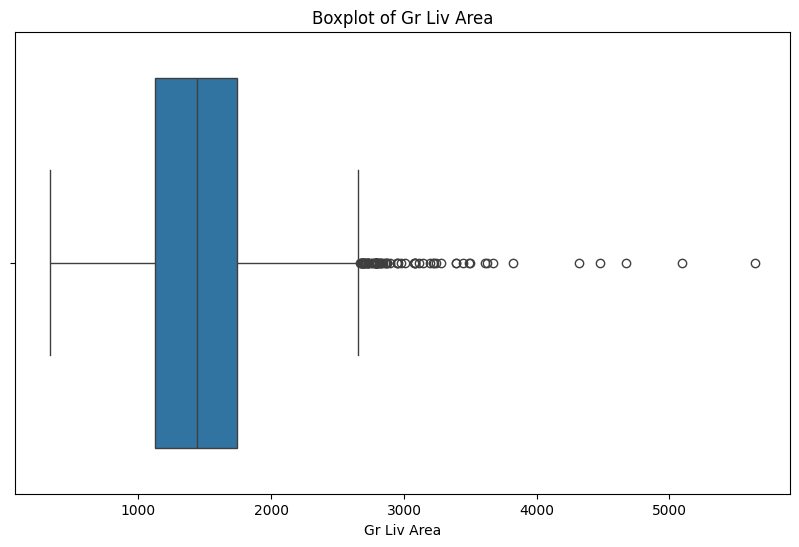

In [8]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=df[x_column])
plt.title(f'Boxplot of {x_column}')
plt.xlabel(x_column)
plt.show()

### Step 3: Interquartile Range (IQR) Method to Identify Outliers

Number of outliers detected by IQR method in Gr Liv Area: 75


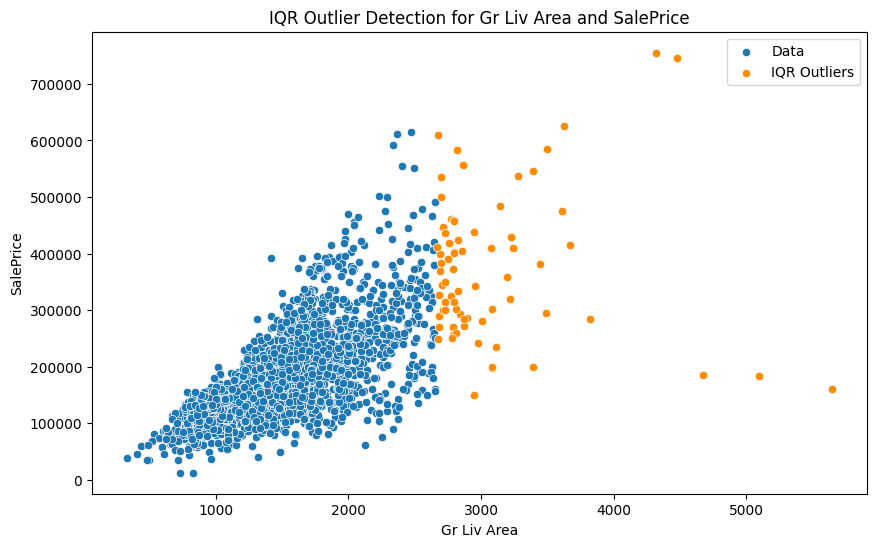

In [9]:
Q1 = df[x_column].quantile(0.25)
Q3 = df[x_column].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers_iqr = df[(df[x_column] < lower_bound) | (df[x_column] > upper_bound)]
print(f"Number of outliers detected by IQR method in {x_column}: {len(outliers_iqr)}")

# add scatter plot for IQR outliers
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df[x_column], y=df[y_column], label='Data')
sns.scatterplot(x=outliers_iqr[x_column], y=outliers_iqr[y_column], color='darkorange', label='IQR Outliers')
plt.title(f'IQR Outlier Detection for {x_column} and {y_column}')
plt.xlabel(x_column)
plt.ylabel(y_column)
plt.legend()
plt.show()


In [10]:
upper_bound

2667.875

### Step 4: Z-Score Method for Outlier Detection

Number of outliers detected by Z-Score method in Gr Liv Area: 25


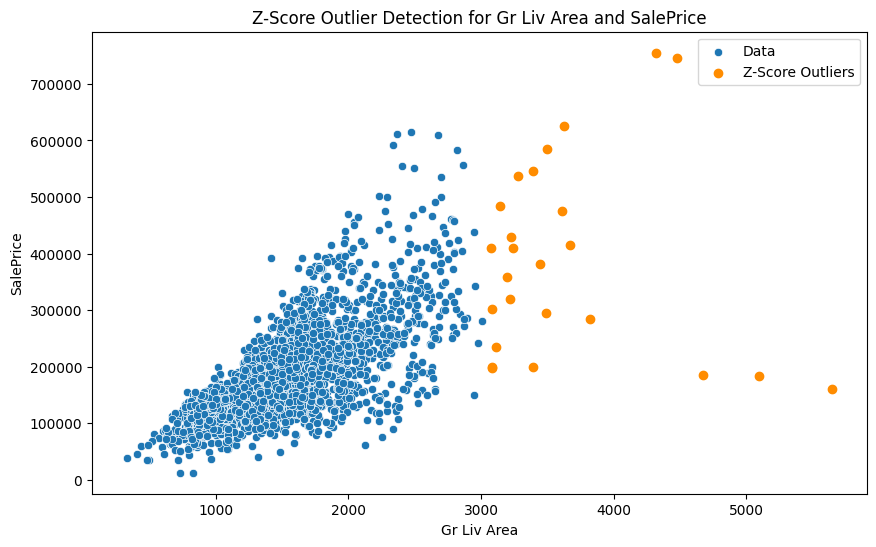

In [12]:
z_scores = np.abs(stats.zscore(df[x_column].dropna()))
outliers_z_score = df[z_scores > 3]
print(f"Number of outliers detected by Z-Score method in {x_column}: {len(outliers_z_score)}")

# add scatter plot for z score anomalies
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df[x_column], y=df[y_column], label='Data')
plt.scatter(outliers_z_score[x_column], outliers_z_score[y_column], color='darkorange', label='Z-Score Outliers')
plt.title(f'Z-Score Outlier Detection for {x_column} and {y_column}')
plt.xlabel(x_column)
plt.ylabel(y_column)
plt.legend()
plt.show()

### Step 5: Cook's Distance to Detect Influential Points

<ipython-input-13-f66e2f66cea5>:8: MatplotlibDeprecationWarning: The 'use_line_collection' parameter of stem() was deprecated in Matplotlib 3.6 and will be removed two minor releases later. If any parameter follows 'use_line_collection', they should be passed as keyword, not positionally.
  plt.stem(np.arange(len(c)), c, markerfmt=',', use_line_collection=True)


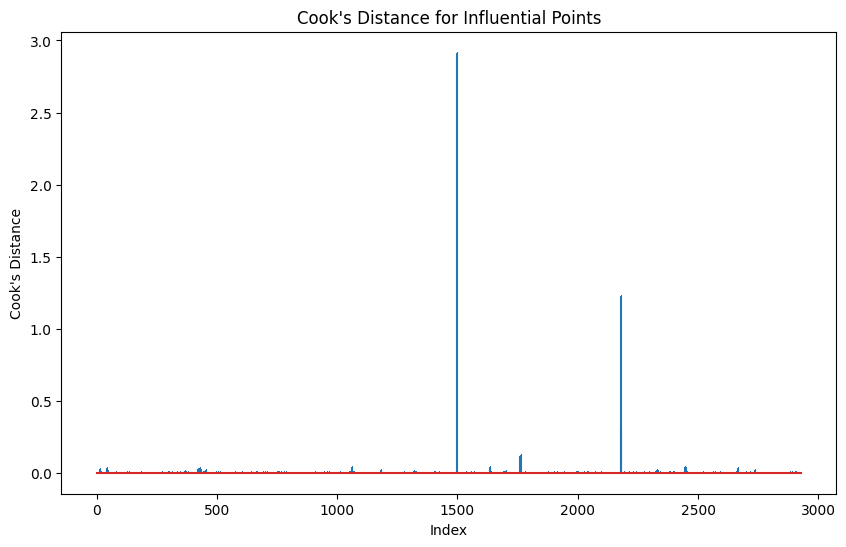

Number of influential points detected by Cook's Distance: 172


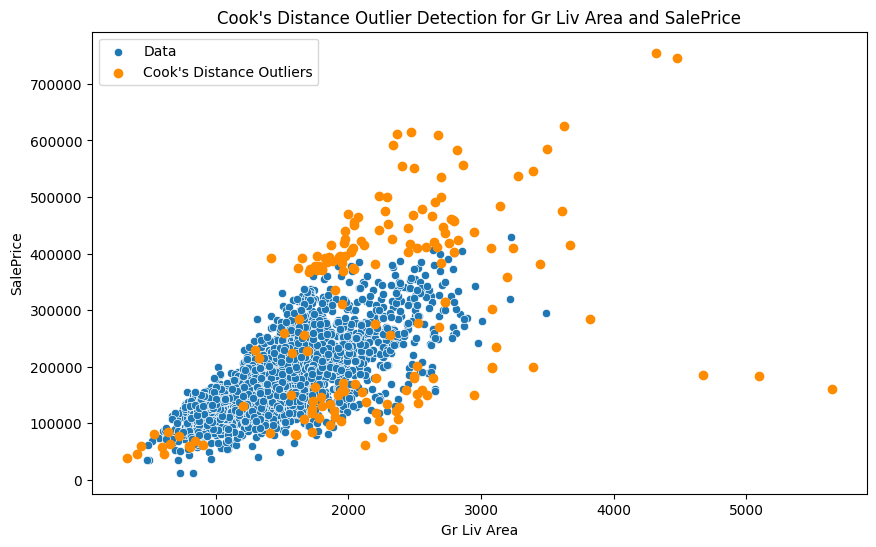

In [13]:
X = df[[x_column, 'Overall Qual', 'Year Built', 'Total Bsmt SF']].dropna()
X = sm.add_constant(X)
y = df[y_column].dropna().loc[X.index]
model = sm.OLS(y, X).fit()
influence = model.get_influence()
(c, _) = influence.cooks_distance
plt.figure(figsize=(10, 6))
plt.stem(np.arange(len(c)), c, markerfmt=',', use_line_collection=True)
plt.title("Cook's Distance for Influential Points")
plt.xlabel("Index")
plt.ylabel("Cook's Distance")
plt.show()
# Identifying points with Cook's distance > 4/n
n = len(df)
cook_outliers = np.where(c > 4/n)[0]
print(f"Number of influential points detected by Cook's Distance: {len(cook_outliers)}")

# add scatterplot for cook's anomalies
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df[x_column], y=df[y_column], label='Data')
plt.scatter(X.iloc[cook_outliers][x_column], y.iloc[cook_outliers], color='darkorange', label='Cook\'s Distance Outliers')
plt.title(f'Cook\'s Distance Outlier Detection for {x_column} and {y_column}')
plt.xlabel(x_column)
plt.ylabel(y_column)
plt.legend()
plt.show()

### Step 6: DBSCAN to Detect Outliers

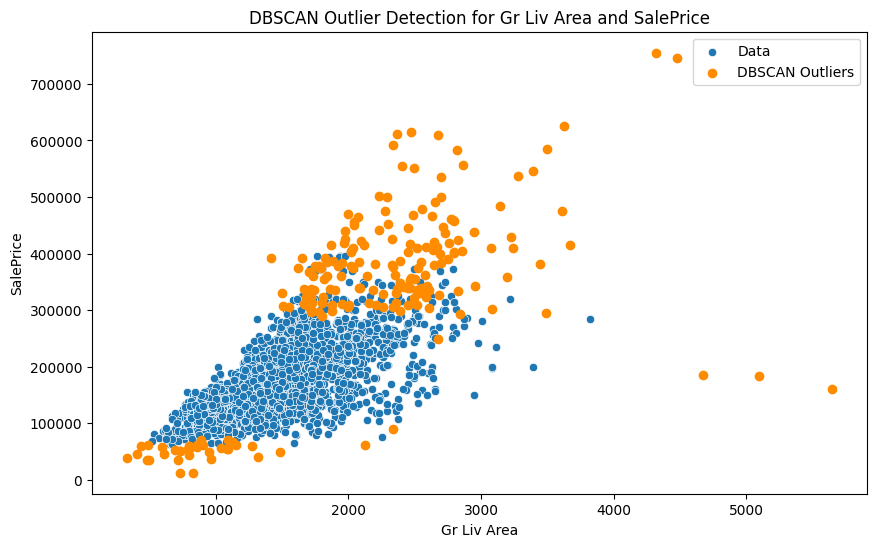

Number of outliers detected by DBSCAN: 207


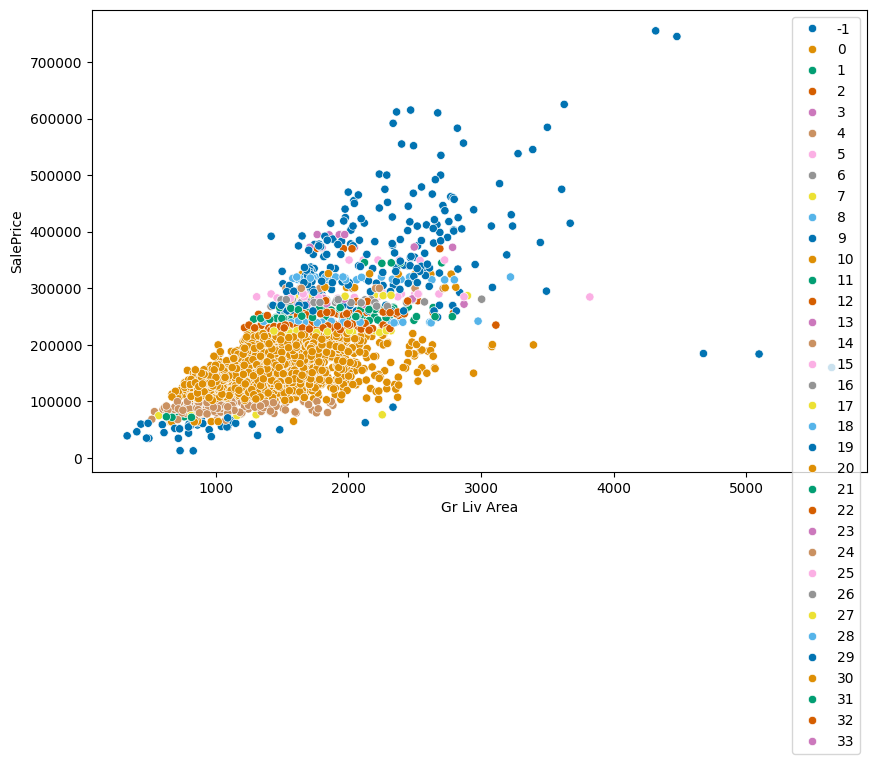

In [16]:
X = df[[x_column, y_column]].dropna()
dbscan = DBSCAN(eps=1000, min_samples=5)
labels = dbscan.fit_predict(X)
outliers_dbscan = X[labels == -1]
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X[x_column], y=X[y_column], label='Data')
plt.scatter(outliers_dbscan[x_column], outliers_dbscan[y_column], color='darkorange', label='DBSCAN Outliers')
plt.title(f'DBSCAN Outlier Detection for {x_column} and {y_column}')
plt.xlabel(x_column)
plt.ylabel(y_column)
plt.legend()
plt.show()

# plot dbscant slusters on scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X[x_column], y=X[y_column], hue=labels, palette='colorblind', legend=True)

print(f"Number of outliers detected by DBSCAN: {len(outliers_dbscan)}")

### Step 7: Isolation Forest for Outlier Detection

Number of outliers detected by Isolation Forest: 147


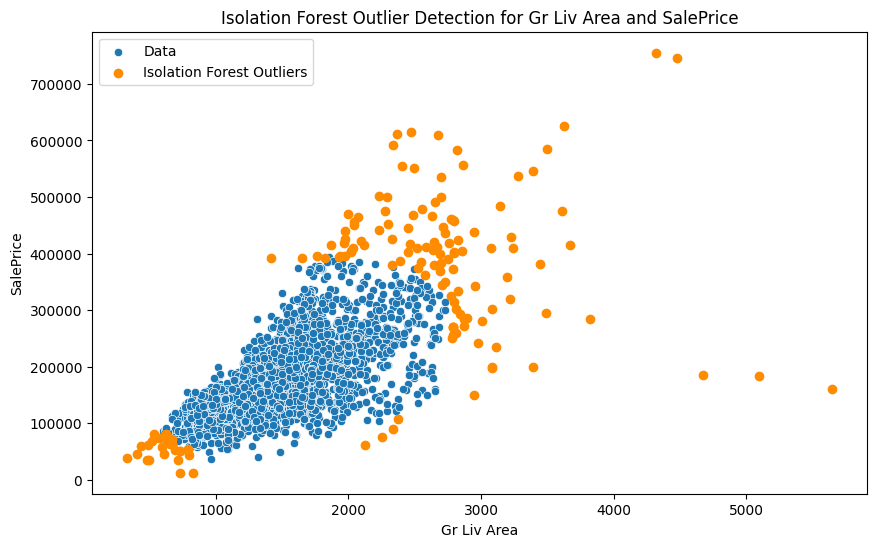

In [17]:
isolation_forest = IsolationForest(contamination=0.05, random_state=42)
X = df[[x_column, y_column]].dropna()
X['anomaly'] = isolation_forest.fit_predict(X)
outliers_isolation_forest = X[X['anomaly'] == -1]
print(f"Number of outliers detected by Isolation Forest: {len(outliers_isolation_forest)}")

# add scatterplot
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X[x_column], y=X[y_column], label='Data')
plt.scatter(outliers_isolation_forest[x_column], outliers_isolation_forest[y_column], color='darkorange', label='Isolation Forest Outliers')
plt.xlabel(x_column)
plt.ylabel(y_column)
plt.title(f'Isolation Forest Outlier Detection for {x_column} and {y_column}')
plt.legend()
plt.show()

### Step 8: Local Outlier Factor (LOF) for Outlier Detection

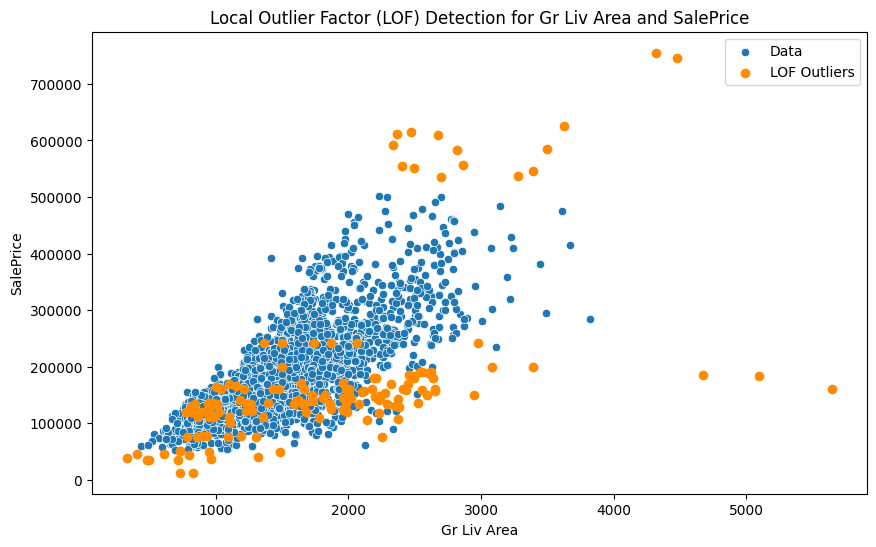

Number of outliers detected by Local Outlier Factor: 147


In [18]:
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
labels_lof = lof.fit_predict(X[[x_column, y_column]])
outliers_lof = X[labels_lof == -1]

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X[x_column], y=X[y_column], label='Data')
plt.scatter(outliers_lof[x_column], outliers_lof[y_column], color='darkorange', label='LOF Outliers')
plt.title(f'Local Outlier Factor (LOF) Detection for {x_column} and {y_column}')
plt.xlabel(x_column)
plt.ylabel(y_column)
plt.legend()
plt.show()

print(f"Number of outliers detected by Local Outlier Factor: {len(outliers_lof)}")

### Step 9: One-Class SVM for Outlier Detection

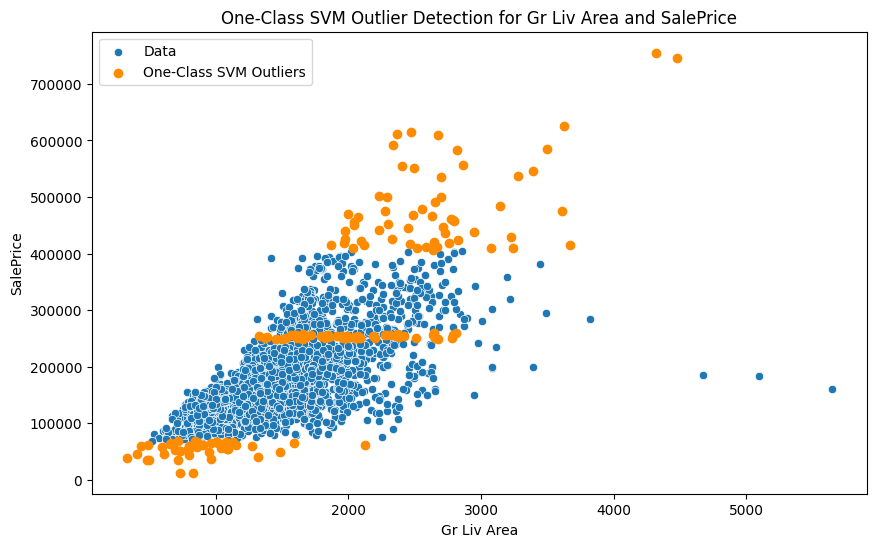

Number of outliers detected by One-Class SVM: 168


In [19]:
ocsvm = OneClassSVM(kernel='rbf', gamma='scale', nu=0.05)
labels_ocsvm = ocsvm.fit_predict(X[[x_column, y_column]])
outliers_ocsvm = X[labels_ocsvm == -1]

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X[x_column], y=X[y_column], label='Data')
plt.scatter(outliers_ocsvm[x_column], outliers_ocsvm[y_column], color='darkorange', label='One-Class SVM Outliers')
plt.title(f'One-Class SVM Outlier Detection for {x_column} and {y_column}')
plt.xlabel(x_column)
plt.ylabel(y_column)
plt.legend()
plt.show()
print(f"Number of outliers detected by One-Class SVM: {len(outliers_ocsvm)}")

### Step 10: Visualizing All Detected Outliers Together

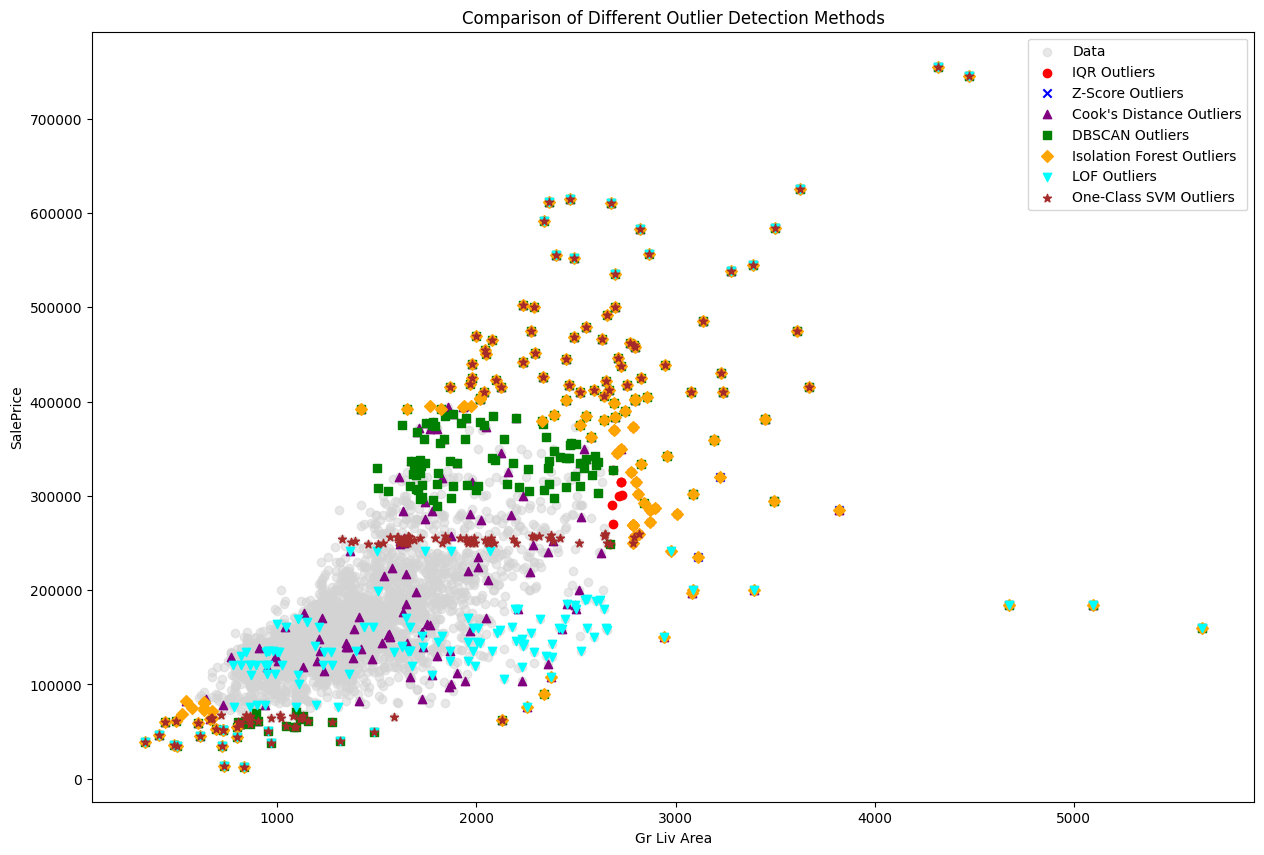

In [20]:
plt.figure(figsize=(15, 10))
plt.scatter(X[x_column], X[y_column], color='lightgray', label='Data', alpha=0.5)

plt.scatter(outliers_iqr[x_column], outliers_iqr[y_column], color='red', label='IQR Outliers', marker='o')
plt.scatter(outliers_z_score[x_column], outliers_z_score[y_column], color='blue', label='Z-Score Outliers', marker='x')
plt.scatter(X.iloc[cook_outliers][x_column], X.iloc[cook_outliers][y_column], color='purple', label="Cook's Distance Outliers", marker='^')
plt.scatter(outliers_dbscan[x_column], outliers_dbscan[y_column], color='green', label='DBSCAN Outliers', marker='s')
plt.scatter(outliers_isolation_forest[x_column], outliers_isolation_forest[y_column], color='orange', label='Isolation Forest Outliers', marker='D')
plt.scatter(outliers_lof[x_column], outliers_lof[y_column], color='cyan', label='LOF Outliers', marker='v')
plt.scatter(outliers_ocsvm[x_column], outliers_ocsvm[y_column], color='brown', label='One-Class SVM Outliers', marker='*')

plt.title('Comparison of Different Outlier Detection Methods')
plt.xlabel(x_column)
plt.ylabel(y_column)
plt.legend()
plt.show()

### Step 11: Multiple Graphs in a Grid for Comparison

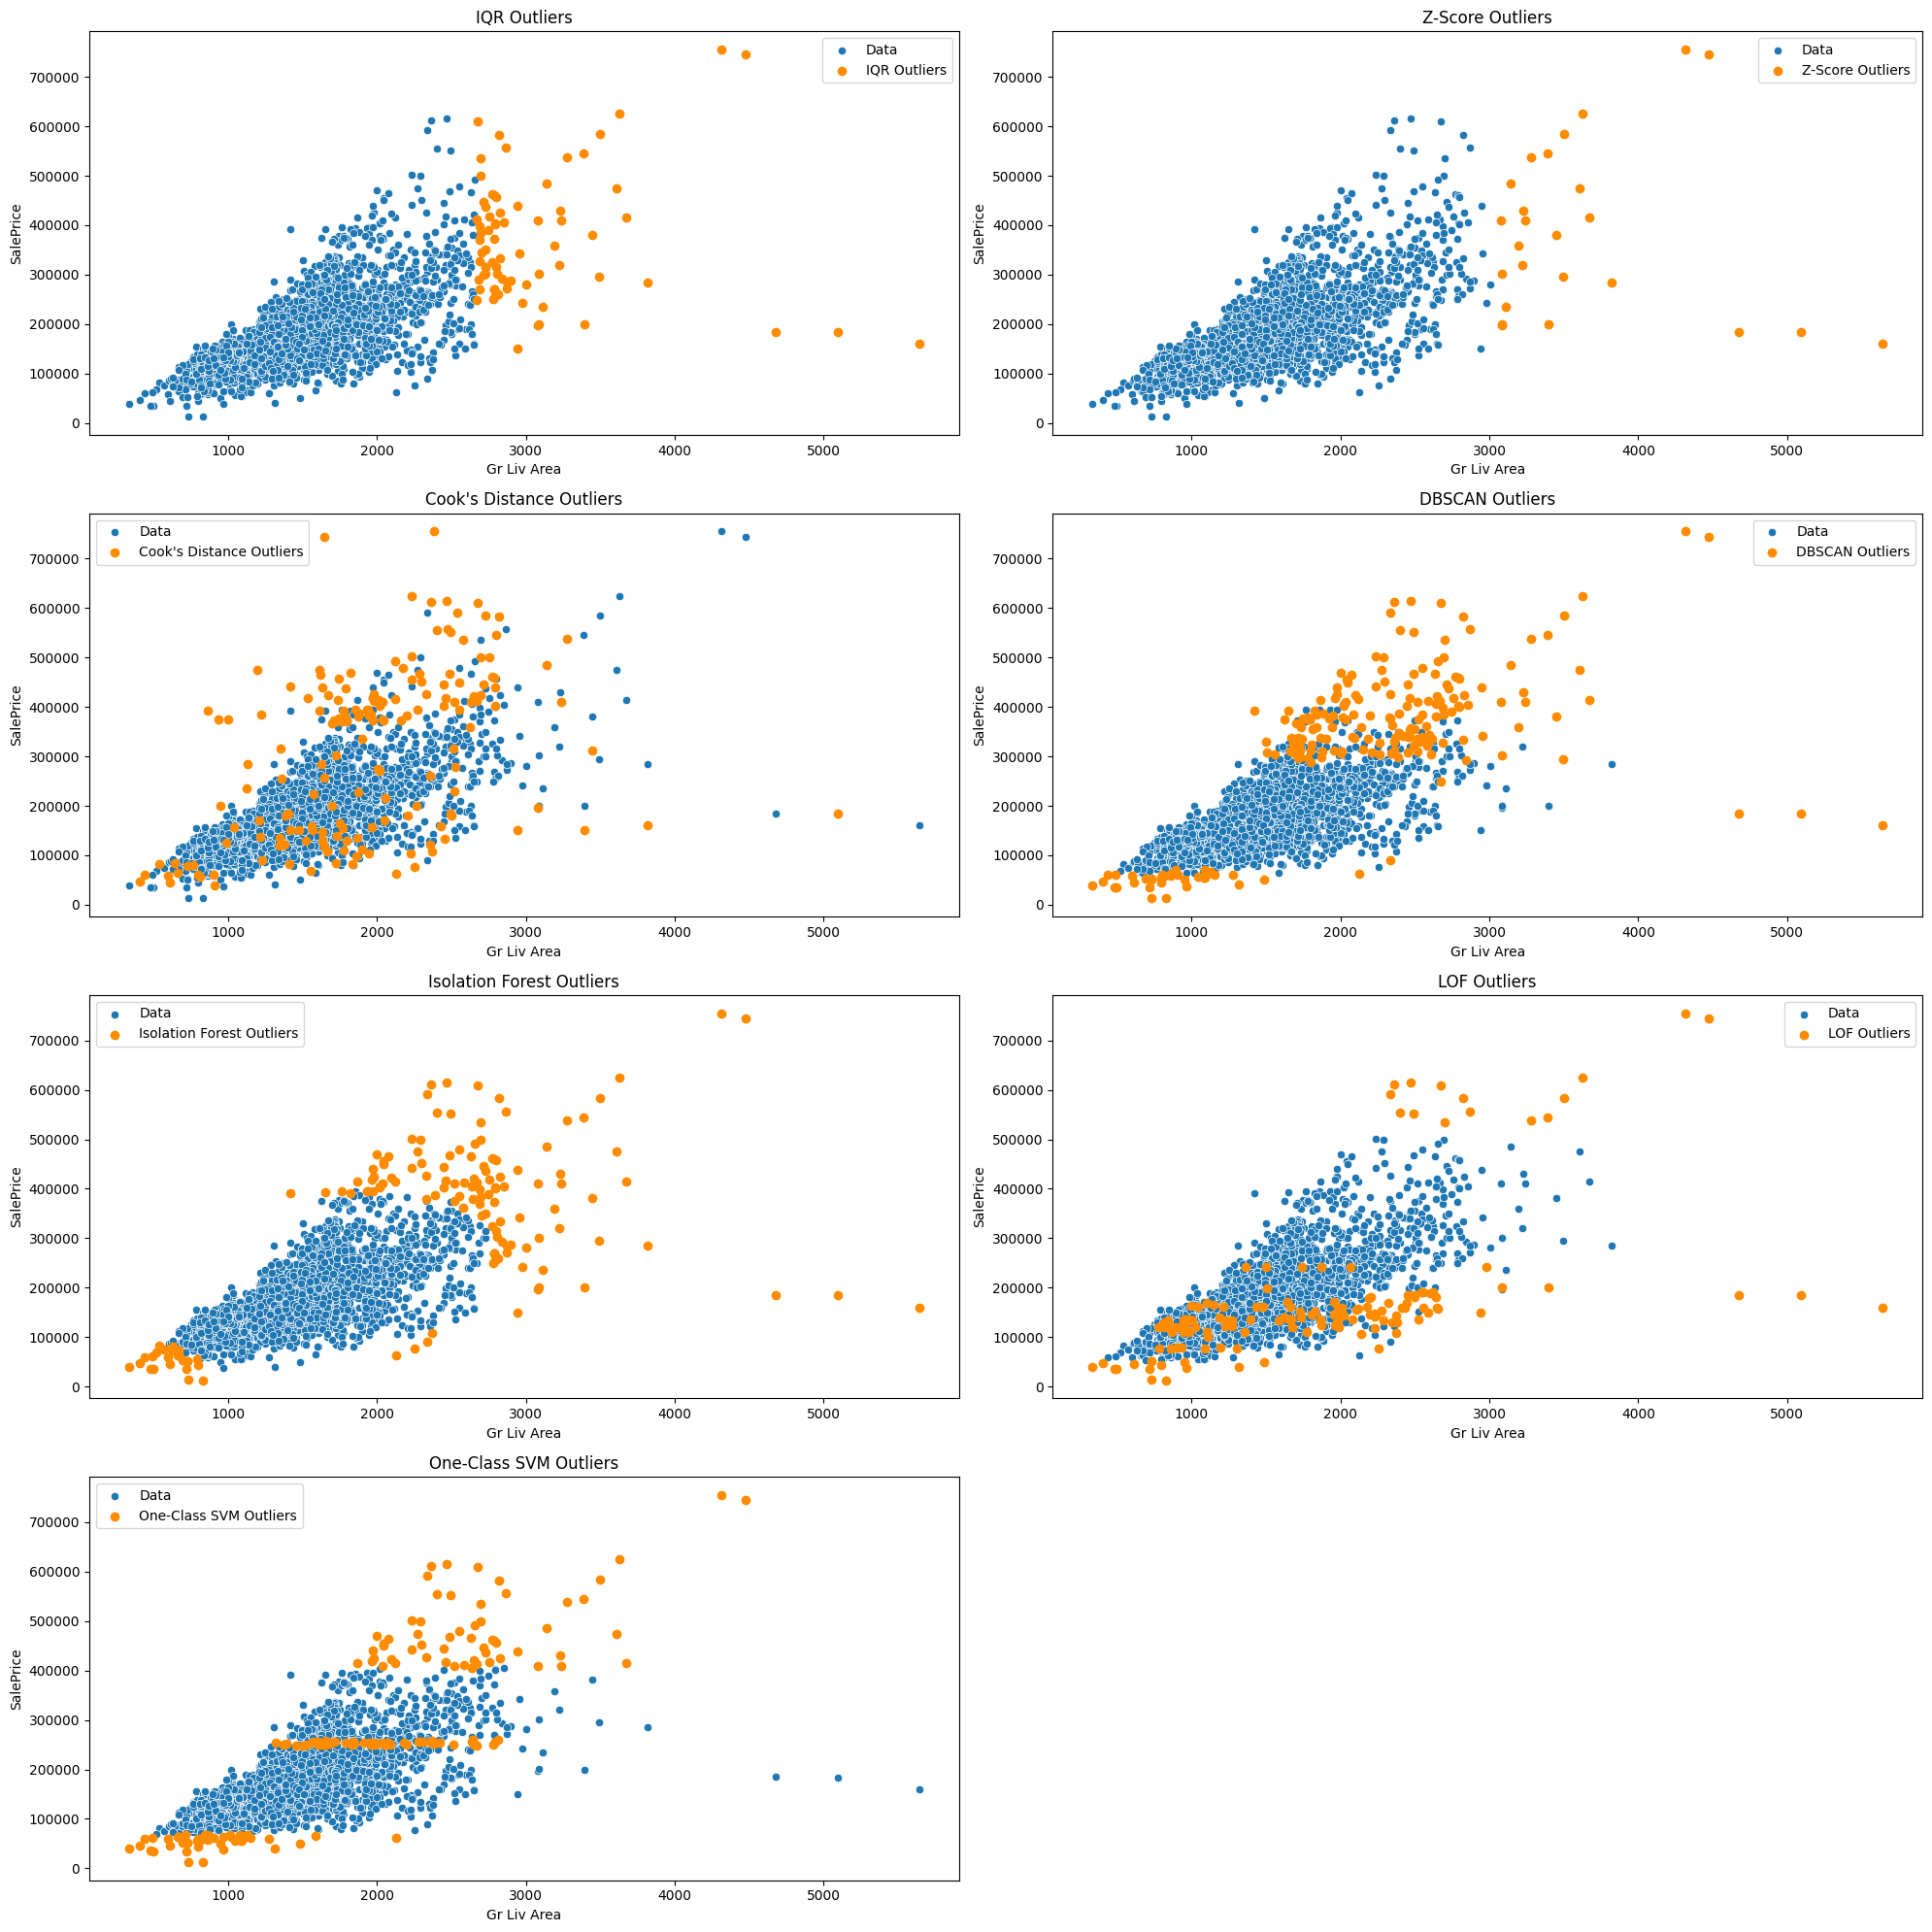

In [21]:
fig, axes = plt.subplots(4, 2, figsize=(20, 20))
axes = axes.flatten()

sns.scatterplot(ax=axes[0], x=df[x_column], y=df[y_column], label='Data')
axes[0].scatter(outliers_iqr[x_column], outliers_iqr[y_column], color='darkorange', label='IQR Outliers')
axes[0].set_title('IQR Outliers')
axes[0].set_xlabel(x_column)
axes[0].set_ylabel(y_column)
axes[0].legend()

sns.scatterplot(ax=axes[1], x=df[x_column], y=df[y_column], label='Data')
axes[1].scatter(outliers_z_score[x_column], outliers_z_score[y_column], color='darkorange', label='Z-Score Outliers')
axes[1].set_title('Z-Score Outliers')
axes[1].set_xlabel(x_column)
axes[1].set_ylabel(y_column)
axes[1].legend()

sns.scatterplot(ax=axes[2], x=df[x_column], y=df[y_column], label='Data')
axes[2].scatter(X.iloc[cook_outliers][x_column], y.iloc[cook_outliers], color='darkorange', label="Cook's Distance Outliers")
axes[2].set_title("Cook's Distance Outliers")
axes[2].set_xlabel(x_column)
axes[2].set_ylabel(y_column)
axes[2].legend()

sns.scatterplot(ax=axes[3], x=df[x_column], y=df[y_column], label='Data')
axes[3].scatter(outliers_dbscan[x_column], outliers_dbscan[y_column], color='darkorange', label='DBSCAN Outliers')
axes[3].set_title('DBSCAN Outliers')
axes[3].set_xlabel(x_column)
axes[3].set_ylabel(y_column)
axes[3].legend()

sns.scatterplot(ax=axes[4], x=df[x_column], y=df[y_column], label='Data')
axes[4].scatter(outliers_isolation_forest[x_column], outliers_isolation_forest[y_column], color='darkorange', label='Isolation Forest Outliers')
axes[4].set_title('Isolation Forest Outliers')
axes[4].set_xlabel(x_column)
axes[4].set_ylabel(y_column)
axes[4].legend()

sns.scatterplot(ax=axes[5], x=df[x_column], y=df[y_column], label='Data')
axes[5].scatter(outliers_lof[x_column], outliers_lof[y_column], color='darkorange', label='LOF Outliers')
axes[5].set_title('LOF Outliers')
axes[5].set_xlabel(x_column)
axes[5].set_ylabel(y_column)
axes[5].legend()

sns.scatterplot(ax=axes[6], x=df[x_column], y=df[y_column], label='Data')
axes[6].scatter(outliers_ocsvm[x_column], outliers_ocsvm[y_column], color='darkorange', label='One-Class SVM Outliers')
axes[6].set_title('One-Class SVM Outliers')
axes[6].set_xlabel(x_column)
axes[6].set_ylabel(y_column)
axes[6].legend()

fig.delaxes(axes[7])
fig.tight_layout()
plt.show()

In [22]:
print("\nExplanation of Outlier Detection Methods:")
print("1. Scatter Plot: Helps visually identify potential outliers based on the data's location and spread.")
print("2. Boxplot: Uses quartiles to visualize outliers beyond the whiskers, which represent 1.5*IQR from Q1 and Q3.")
print("3. IQR Method: Identifies values outside the range [Q1 - 1.5*IQR, Q3 + 1.5*IQR] as outliers.")
print("4. Z-Score: Measures how many standard deviations a value is from the mean. Common threshold: Z > 3 or Z < -3.")
print("5. Cook's Distance: Measures the influence of individual points on a regression model. Points with high Cook's distance are potential outliers or influential observations.")
print("6. DBSCAN: A density-based clustering algorithm that detects outliers in low-density regions. The 'eps' parameter was adjusted for better separation.")
print("7. Isolation Forest: An ensemble method that isolates observations to detect anomalies, useful for high-dimensional data. The 'contamination' parameter was set to 0.05.")
print("8. Local Outlier Factor (LOF): Measures the local density deviation of a given data point with respect to its neighbors.")
print("9. One-Class SVM: A type of SVM used for anomaly detection, which tries to find a boundary that separates normal data from outliers.")


Explanation of Outlier Detection Methods:
1. Scatter Plot: Helps visually identify potential outliers based on the data's location and spread.
2. Boxplot: Uses quartiles to visualize outliers beyond the whiskers, which represent 1.5*IQR from Q1 and Q3.
3. IQR Method: Identifies values outside the range [Q1 - 1.5*IQR, Q3 + 1.5*IQR] as outliers.
4. Z-Score: Measures how many standard deviations a value is from the mean. Common threshold: Z > 3 or Z < -3.
5. Cook's Distance: Measures the influence of individual points on a regression model. Points with high Cook's distance are potential outliers or influential observations.
6. DBSCAN: A density-based clustering algorithm that detects outliers in low-density regions. The 'eps' parameter was adjusted for better separation.
7. Isolation Forest: An ensemble method that isolates observations to detect anomalies, useful for high-dimensional data. The 'contamination' parameter was set to 0.05.
8. Local Outlier Factor (LOF): Measures the local d

=======================

# Worth taking a look:
https://scikit-learn.org/1.5/modules/outlier_detection.html